In this notebook, we demonstrate usage of SpotSweeper_py on a public Visium dataset. Specifically, the sample is taken from human breast cancer, FFPE tissue block using IF. The data summary could be obtained here: https://www.10xgenomics.com/datasets/gene-and-protein-expression-library-of-human-breast-cancer-cytassist-ffpe-2-standard

In [1]:
from typing import Optional, Sequence
import matplotlib.pyplot as plt

# HELPER FUNCTIONS USED LATER
def plot_qc_metric_with_outliers(
    adata,
    sample_id: str = "region",
    sample: Optional[str] = None,
    metric: str = "total_counts",
    outliers: str = "qc_outlier",
    point_size: float = 2,
    colors: Sequence[str] = ("white", "black"),
    stroke: float = 1.0,
    coord_key: str = "spatial",
    title_prefix: str = "QC Metric",
    title: Optional[str] = None,  # customizable title
):
    import pandas as pd
    import numpy as np
    from matplotlib.colors import LinearSegmentedColormap

    # Select sample
    if sample_id is None or sample_id not in adata.obs.columns:
        adata_sub = adata.copy()  # use all spots (single sample)
    else:
        if sample is None:
            sample = adata.obs[sample_id].unique()[0]
        mask = np.array(adata.obs[sample_id] == sample)
        adata_sub = adata[mask].copy()

    # Build dataframe
    coords = np.array(adata_sub.obsm[coord_key])
    df = pd.DataFrame(coords, columns=["x", "y"], index=adata_sub.obs_names)
    df[metric] = adata_sub.obs[metric].astype(float)
    df["outlier"] = adata_sub.obs[outliers].astype(bool)
    
    # Condition: nonzero counts & outliers
    df["color_condition"] = (df[metric] > 0) & (df["outlier"])

    # Color scale
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    # Base plot
    plt.figure(figsize=(6, 6))
    base = plt.scatter(
        df["x"], df["y"],
        c=df[metric], cmap=cmap, s=point_size**2,
        linewidths=0, rasterized=True
    )

    # Highlighted overlay
    highlighted = df[df["color_condition"]]
    print(f"Colored = {len(highlighted):,} / {len(df):,} "
          f"({len(highlighted)/len(df)*100:.2f}%)")

    plt.scatter(
        highlighted["x"], highlighted["y"],
        facecolors="none",
        edgecolors="red",
        linewidths=stroke * 1.5,
        alpha=0.8,
        s=(point_size * 1.4) ** 2,
    )

    # Axes and labels
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.colorbar(base, label=metric)

    # Title: use custom if provided
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Global {title_prefix}: {metric} ({sample})")

    plt.xlabel("x")
    plt.ylabel("y")

        # Legend for outliers vs non-outliers
    import matplotlib.lines as mlines
    non_out = mlines.Line2D(
        [], [], marker="o", linestyle="None",
        markerfacecolor="none", markeredgecolor="black",
        markersize=6, label="Non-outlier",
    )
    out = mlines.Line2D(
        [], [], marker="o", linestyle="None",
        markerfacecolor="none", markeredgecolor="red",
        markersize=6, label="Outlier",
    )
    plt.legend(handles=[non_out, out], loc="upper right")
    
    plt.tight_layout()
    return plt

To get started with the analysis, we process the dataset and convert into AnnData object.

In [2]:
import squidpy as sq
adata = sq.read.visium(
    path="/users/xchen5/paper_spotsweeperpy/Visium",
    counts_file="CytAssist_FFPE_Protein_Expression_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
)

/users/xchen5/.local/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Similar analyses are conducted below (see Visium HD notebook).

**Global QC: Summary Statistics**

In [3]:
import scanpy as sc
import numpy as np
from scipy.stats import median_abs_deviation

adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-') # mark mitochondrial genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True) 
adata.obs["log_total_counts"] = np.log1p(adata.obs["total_counts"])

def is_outlier(vec, nmads=3, log=False, direction='both'):
    arr = np.log1p(vec) if log else np.asarray(vec)
    med = np.nanmedian(arr)
    mad = median_abs_deviation(arr, nan_policy='omit')
    lower = med - nmads * mad
    upper = med + nmads * mad
    if direction == 'lower':
        return arr < lower
    elif direction == 'higher':
        return arr > upper
    else:
        return (arr < lower) | (arr > upper)
    
adata.obs['low_counts_outlier'] = is_outlier(adata.obs['total_counts'], direction='lower')
adata.obs['low_log_counts_outlier'] = is_outlier(adata.obs['log_total_counts'], direction='lower')
adata.obs['high_mt_outlier']   = is_outlier(adata.obs['pct_counts_mt'], direction='higher')
adata.obs['low_genes_outlier'] = is_outlier(adata.obs['n_genes_by_counts'], direction='lower')

# combine into one global flag
adata.obs['all_metrics_outlier'] = (
    adata.obs['low_counts_outlier'] | adata.obs['low_log_counts_outlier'] | adata.obs['high_mt_outlier'] | adata.obs['low_genes_outlier']
)

print(adata.obs['low_counts_outlier'].value_counts())
print(adata.obs['low_log_counts_outlier'].value_counts())
print(adata.obs['high_mt_outlier'].value_counts())
print(adata.obs['low_genes_outlier'].value_counts())
print(adata.obs['all_metrics_outlier'].value_counts())

# Summarize and print percentages
for col in [
    "low_counts_outlier",
    "low_log_counts_outlier",
    "high_mt_outlier",
    "low_genes_outlier",
    "all_metrics_outlier"
]:
    flagged = adata.obs[col].sum()             # number of True values
    total = adata.n_obs                        # total spots
    perc = flagged / total * 100
    print(f"{col}: {flagged}/{total} spots ({perc:.2f}%) flagged")

low_counts_outlier
False    4169
Name: count, dtype: int64
low_log_counts_outlier
False    3940
True      229
Name: count, dtype: int64
high_mt_outlier
False    3561
True      608
Name: count, dtype: int64
low_genes_outlier
False    4019
True      150
Name: count, dtype: int64
all_metrics_outlier
False    3334
True      835
Name: count, dtype: int64
low_counts_outlier: 0/4169 spots (0.00%) flagged
low_log_counts_outlier: 229/4169 spots (5.49%) flagged
high_mt_outlier: 608/4169 spots (14.58%) flagged
low_genes_outlier: 150/4169 spots (3.60%) flagged
all_metrics_outlier: 835/4169 spots (20.03%) flagged


**Total Counts**

Spotplot:

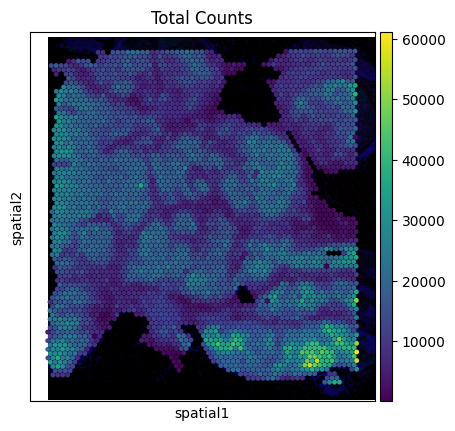

In [4]:
sc.pl.spatial(
    adata,
    color="total_counts",  
    cmap="viridis",
    size=1.4,
    title="Total Counts",
)

Global QC Plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Colored = 0 / 4,169 (0.00%)


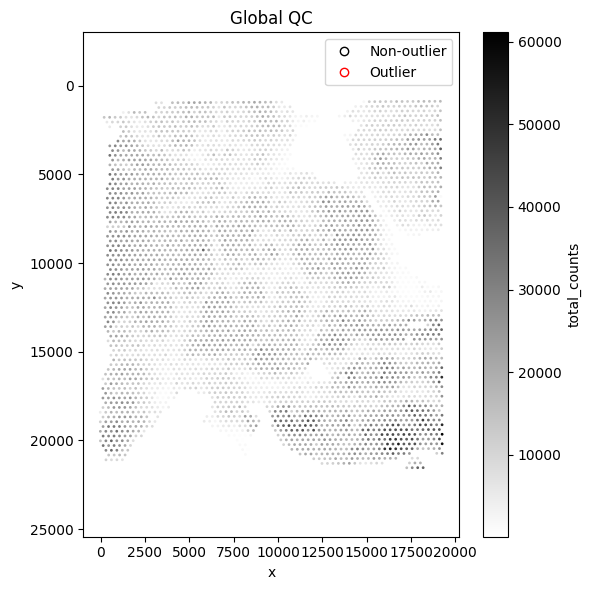

In [5]:
plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="total_counts",
    outliers="low_counts_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Global QC"
)
plt.show()

Note no outliers flagged!

Then, we apply SpotSweeper on the data, with respect to the total counts metric. In the figure, the red spots are spots that are flagged as low outliers with respect to the total counts metric.  
Runtime on a compute node: 1.2 seconds.

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


total_counts_outliers
False    4128
True       41
Name: count, dtype: int64

Flagged: 41/4169 spots (0.98%)


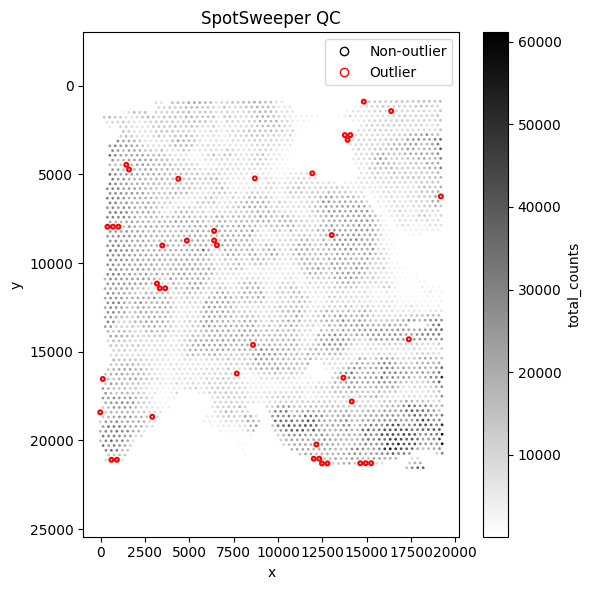

In [6]:
import spotsweeper.local_outliers as lo
import spotsweeper.plot_QC as plot_QC

adata.obs["region"] = "CytAssist_FFPE_Protein_Expression_Human_Breast_Cancer" # define a region column for the data

lo.local_outliers(adata, metric = "total_counts", sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "total_counts", outliers="total_counts_outliers", title="SpotSweeper QC", legend=True) # plot outliers

# print summary of outliers detected
col = "total_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

We then repeat for log total counts, number of genes by counts, and % mitochondrial counts metrics.

**Log Total Counts:**

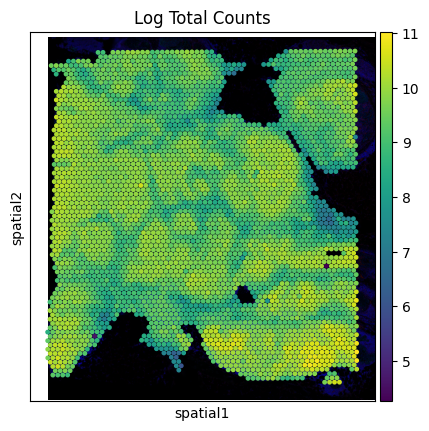

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Colored = 229 / 4,169 (5.49%)


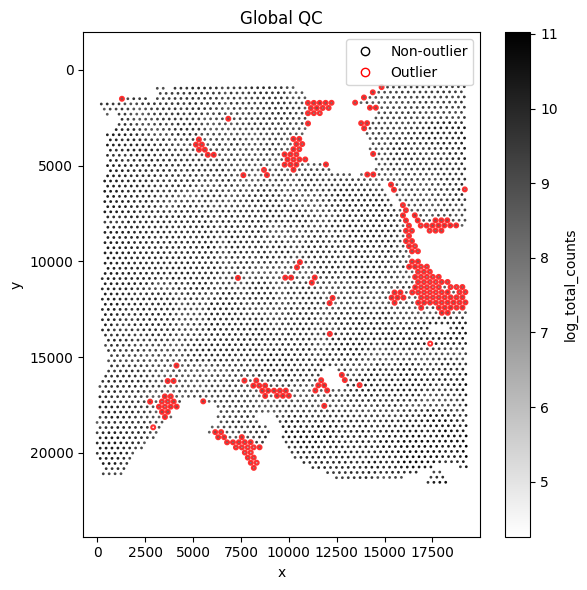

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


log_total_counts_outliers
False    4122
True       47
Name: count, dtype: int64

Flagged: 47/4169 spots (1.13%)


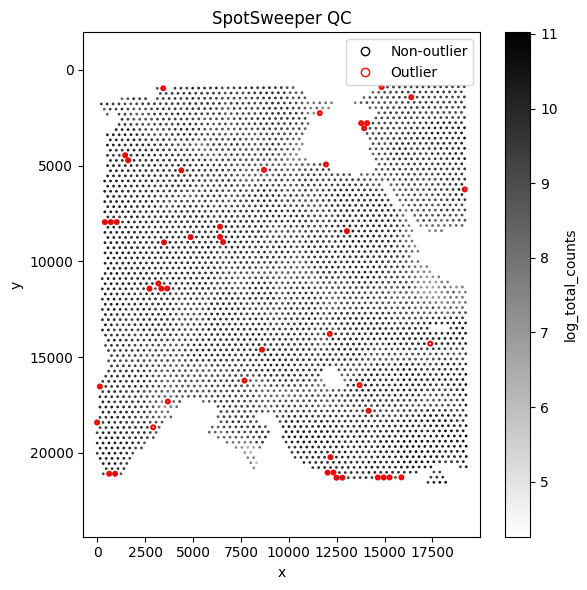

In [7]:
sc.pl.spatial(
    adata,
    color="log_total_counts",  
    cmap="viridis",
    size=1.4,
    title="Log Total Counts",
)

plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="log_total_counts",
    outliers="low_log_counts_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Global QC"
)
plt.show()

lo.local_outliers(adata, metric = "log_total_counts", sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="SpotSweeper QC", legend=True) # plot outliers
# print summary of outliers detected
col = "log_total_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

**Number of genes by counts**

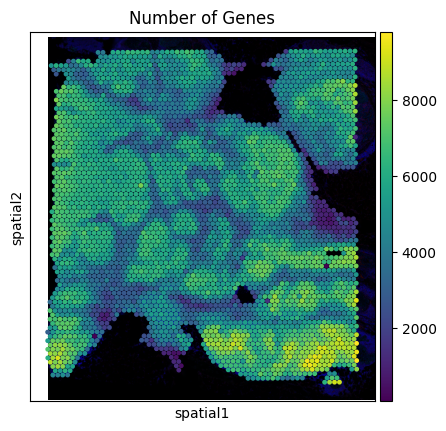

Colored = 150 / 4,169 (3.60%)


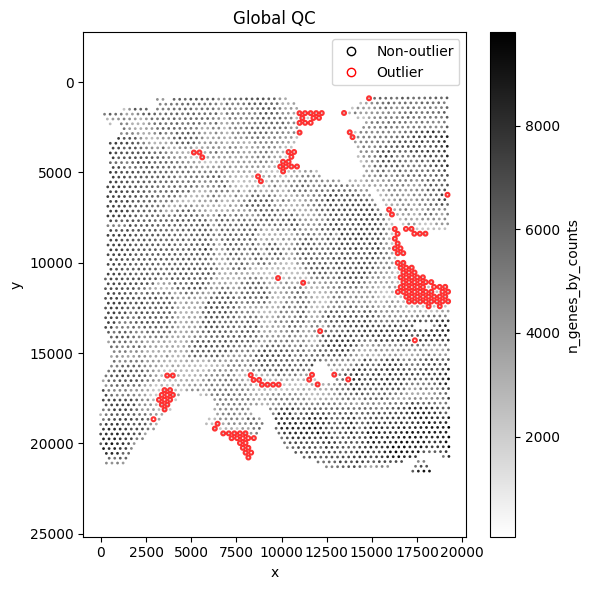

n_genes_by_counts_outliers
False    4089
True       80
Name: count, dtype: int64

Flagged: 80/4169 spots (1.92%)


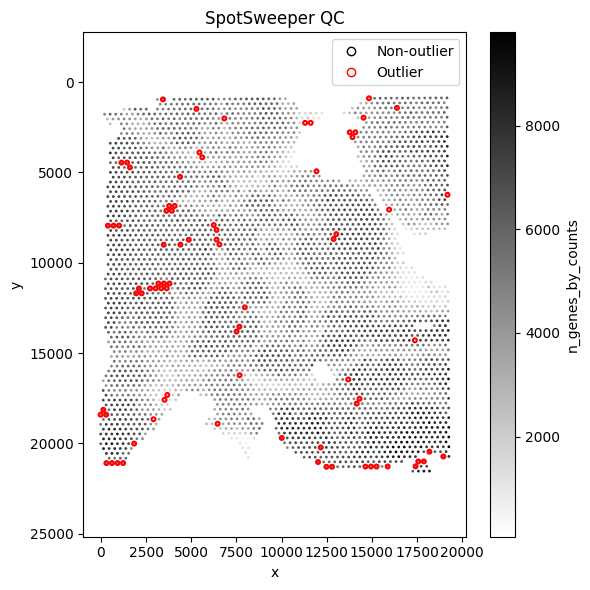

In [13]:
sc.pl.spatial(
    adata,
    color="n_genes_by_counts",  
    cmap="viridis",
    size=1.4,
    title="Number of Genes",
)

plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="n_genes_by_counts",
    outliers="low_genes_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Global QC"
)
plt.show()

lo.local_outliers(adata, metric = "n_genes_by_counts", sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "n_genes_by_counts", outliers="n_genes_by_counts_outliers", title="SpotSweeper QC", legend=True) # plot outliers
# print summary of outliers detected
col = "n_genes_by_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

**% mitochondrial counts:**

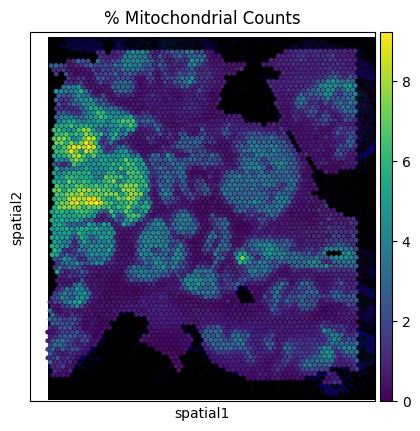

Colored = 608 / 4,169 (14.58%)


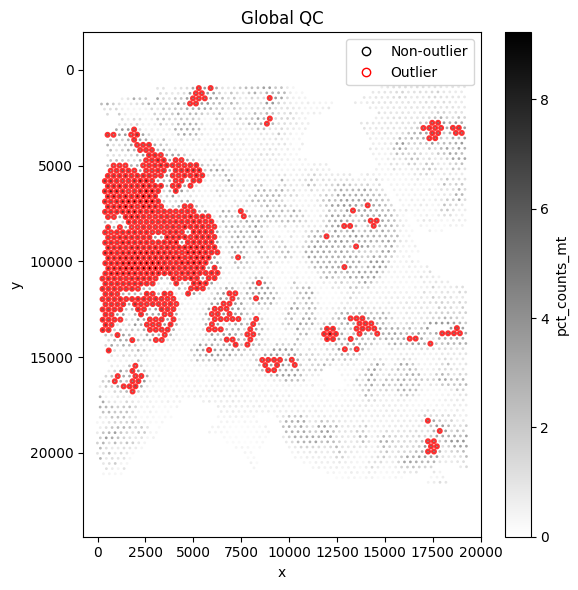

pct_counts_mt_outliers
False    4153
True       16
Name: count, dtype: int64

Flagged: 16/4169 spots (0.38%)


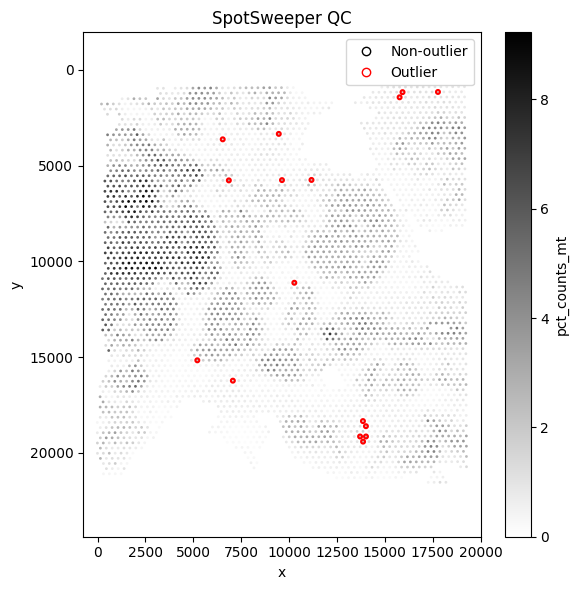

In [12]:
sc.pl.spatial(
    adata,
    color="pct_counts_mt",  
    cmap="viridis",
    size=1.4,
    title="% Mitochondrial Counts",
)

plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="pct_counts_mt",
    outliers="high_mt_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Global QC"
)
plt.show()

lo.local_outliers(adata, metric = "pct_counts_mt", direction = "higher", sample_key = "region")
plot_QC.plot_qc_metrics(adata,"region", metric = "pct_counts_mt", outliers="pct_counts_mt_outliers", title="SpotSweeper QC", legend=True) # plot outliers
# print summary of outliers detected
col = "pct_counts_mt_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

**Violin Plots based on Local z-scores**

Global Outlier Violin Plots:

/tmp/ipykernel_267701/679951601.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_267701/679951601.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_267701/679951601.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_267701/679951601.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)


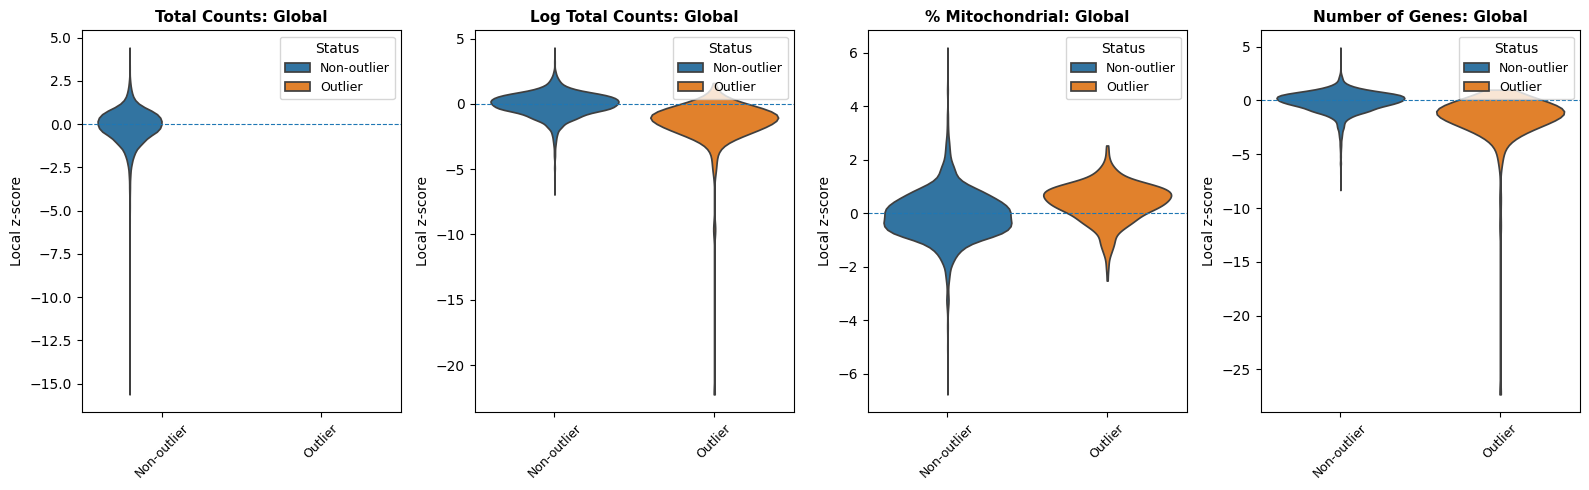

In [10]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

adata.var_names_make_unique()

for col in ['low_counts_outlier', 'low_log_counts_outlier', 'high_mt_outlier', 'low_genes_outlier']:
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=[False, True])

# Map from raw metric to its *local z-scored* version in adata.obs
metric_map = {
    'total_counts': 'total_counts_z',
    'log_total_counts': 'log_total_counts_z',
    'pct_counts_mt': 'pct_counts_mt_z',
    'n_genes_by_counts': 'n_genes_by_counts_z',
}

# (z-scored metric obs key, flag, readable title, y-axis label)
pairs = [
    (metric_map['total_counts'],       'low_counts_outlier',
     'Total Counts: Global',       'Local z-score'),
    (metric_map['log_total_counts'],   'low_log_counts_outlier',
     'Log Total Counts: Global',   'Local z-score'),
    (metric_map['pct_counts_mt'],      'high_mt_outlier',
     '% Mitochondrial: Global',    'Local z-score'),
    (metric_map['n_genes_by_counts'],  'low_genes_outlier',
     'Number of Genes: Global',    'Local z-score')
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title, ylabel) in zip(axes, pairs):
    sc.pl.violin(
        adata,
        keys=metric, # local z-scored metrics
        groupby=flag,
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)

    # Replace generic x-axis tick labels (True/False -> Outlier/Non-Outlier)
    ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, ['Non-outlier', 'Outlier'],
                  title="Status", loc='upper right',
                  fontsize=9, title_fontsize=10)

    # add horizontal line at 0
    ax.axhline(0, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

Local Outlier Violin Plots:

/tmp/ipykernel_267701/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_267701/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_267701/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_267701/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)


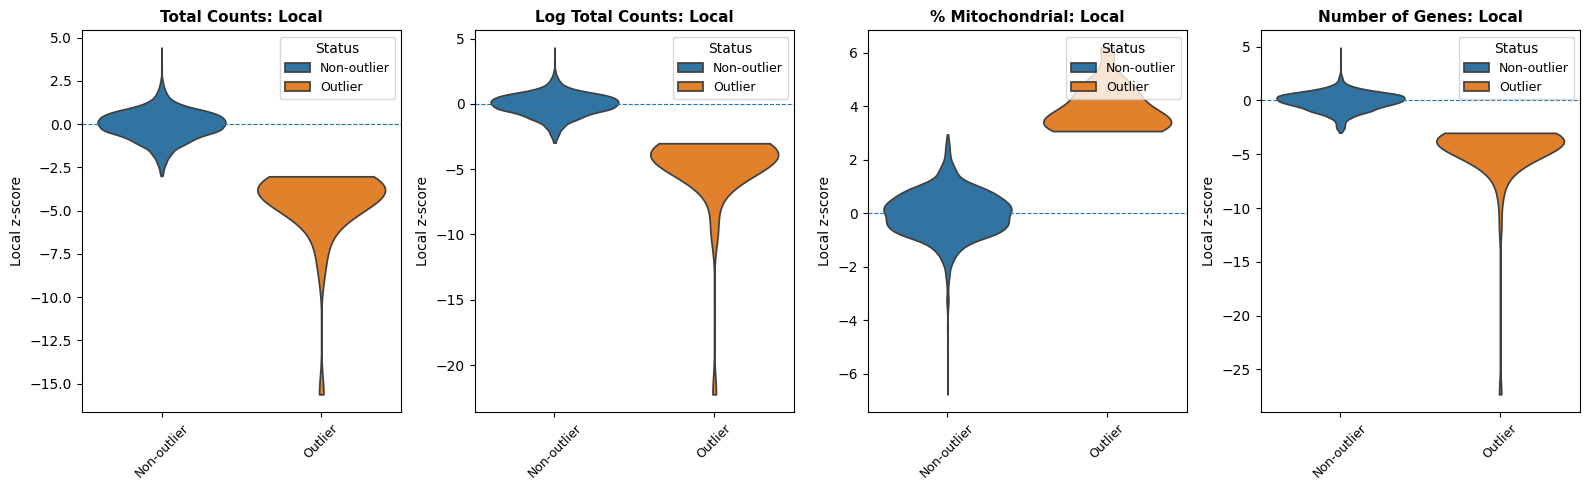

In [11]:
adata.var_names_make_unique()

# Ensure boolean -> categorical with consistent ordering
for col in ['total_counts_outliers', 'log_total_counts_outliers',
            'n_genes_by_counts_outliers', 'pct_counts_mt_outliers']:
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=[False, True])

# Map raw metric -> local z-scored metric
metric_map = {
    'total_counts': 'total_counts_z',
    'log_total_counts': 'log_total_counts_z',
    'pct_counts_mt': 'pct_counts_mt_z',
    'n_genes_by_counts': 'n_genes_by_counts_z',
}

# (z-metric, local-flag, plot title)
pairs = [
    (metric_map['total_counts'],      'total_counts_outliers',      'Total Counts: Local'),
    (metric_map['log_total_counts'],  'log_total_counts_outliers',  'Log Total Counts: Local'),
    (metric_map['pct_counts_mt'],     'pct_counts_mt_outliers',     '% Mitochondrial: Local'),
    (metric_map['n_genes_by_counts'], 'n_genes_by_counts_outliers', 'Number of Genes: Local'),
]

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title) in zip(axes, pairs):
    sc.pl.violin(
        adata,
        keys=metric,  # use local z-score metrics
        groupby=flag,  
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Local z-score", fontsize=10)

    # Cleaner X-axis
    ax.set_xlabel("")
    ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles,
            ['Non-outlier', 'Outlier'],
            title="Status",
            loc='upper right',
            fontsize=9,
            title_fontsize=10
        )

    # Reference line
    ax.axhline(0, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

Calculation of "Any metric flagged" for local column in the table:

In [25]:
outlier_cols = [c for c in adata.obs.columns if c.endswith("_outliers")]
adata.obs["any_local_metric_outlier"] = adata.obs[outlier_cols].any(axis=1)
flagged = adata.obs["any_local_metric_outlier"].sum()
total = adata.n_obs
pct = flagged / total * 100

print(f"Any-metric outlier: {flagged}/{total} spots ({pct:.2f}%)")

Any-metric outlier: 101/4169 spots (2.42%)


Additional Investigation: Are all local outliers also global outliers?

In [4]:
import pandas as pd

global_flag = adata.obs["all_metrics_outlier"].astype(bool)
local_flag  = adata.obs["any_local_metric_outlier"].astype(bool)
local_subset_global = ((local_flag & ~global_flag).sum() == 0)
print("Are ALL local outliers also global outliers?:", local_subset_global)


local_not_global = (local_flag & ~global_flag).sum()
print("Local but NOT global:", local_not_global)

pd.crosstab(global_flag, local_flag,
                  rownames=["Global"], colnames=["Local"])

Are ALL local outliers also global outliers?: False
Local but NOT global: 75


Local,False,True
Global,,
False,3259,75
True,809,26


Check spatial locations of (1) Local False, Global True and (2) Local True, Global False. Are there any trends?

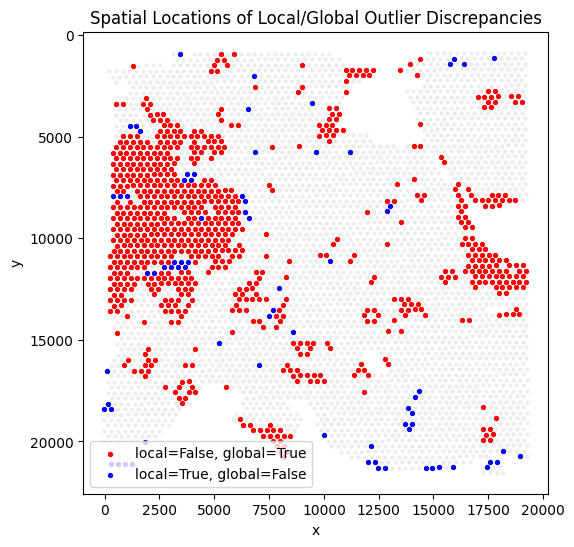

In [5]:
import numpy as np

group_A = (~local_flag) & (global_flag)   # local false, global true
group_B = (local_flag) & (~global_flag)   # local true, global false

coords = adata.obsm["spatial"]
x = coords[:, 0]
y = coords[:, 1]

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Plot all points faintly for context
plt.scatter(x, y, s=5, c="lightgray", alpha=0.3)

# Group A: local False, global True
plt.scatter(x[group_A], y[group_A], s=8, c="red", label="local=False, global=True")

# Group B: local True, global False
plt.scatter(x[group_B], y[group_B], s=8, c="blue", label="local=True, global=False")

plt.legend()
plt.gca().invert_yaxis()  # Visium coordinate convention
plt.title("Spatial Locations of Local/Global Outlier Discrepancies")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [ ]:
# write into a .h5ad file for future usage
# import scanpy as sc
# adata = sc.read_h5ad("/users/xchen5/visium.h5ad")
adata.write("/users/xchen5/visium.h5ad")